In [2]:
# Prathmesh Durge, 23070521109 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

In [3]:
data = pd.read_csv("Housing.csv")

# One-hot encoding for categorical columns
data = pd.get_dummies(data, drop_first=True)

# Features and Target
X = data.drop("price", axis=1)
y = data["price"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
baseline = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

baseline.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_base = baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

In [ ]:
l2_model = keras.Sequential([
    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(X_train.shape[1],)
    ),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(1)
])

l2_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_l2 = l2_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

In [ ]:
dropout_model = keras.Sequential([

    layers.Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    layers.Dropout(0.5),

    layers.Dense(
        32,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(1)
])

dropout_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_dropout = dropout_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

In [9]:
loss, mae = baseline.evaluate(X_test, y_test)

pred = baseline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nBaseline Model")
print("MAE :", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30108792389632.0000 - mae: 5005952.0000 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Baseline Model
MAE : 5005952.0
RMSE: 5487147.737438823


In [10]:
loss, mae = l2_model.evaluate(X_test, y_test)

pred = l2_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nL2 Regularization Model")
print("MAE :", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 30082949185536.0000 - mae: 5004041.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

L2 Regularization Model
MAE : 5004041.0
RMSE: 5484792.155700342


In [ ]:
loss, mae = dropout_model.evaluate(X_test, y_test)

pred = dropout_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))


In [13]:

print("\nDropout Model")
print("MAE :", mae)
print("RMSE:", rmse)


Dropout Model
MAE : 5005032.5
RMSE: 5486065.067641834


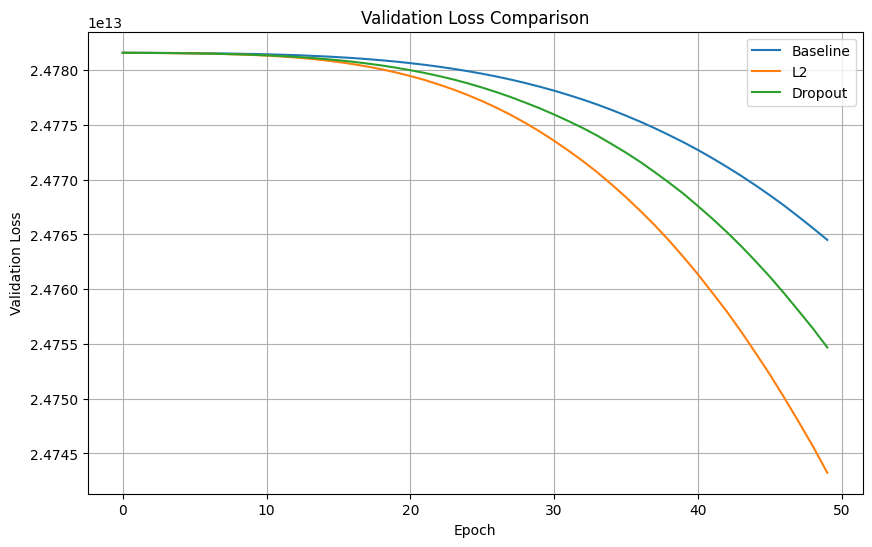

In [12]:
plt.figure(figsize=(10,6))

plt.plot(history_base.history['val_loss'], label='Baseline')

plt.plot(history_l2.history['val_loss'], label='L2')

plt.plot(history_dropout.history['val_loss'], label='Dropout')

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()